In [1]:
from data_meta_map.wasserstein_embedder import WassersteinEmbedder
from data_meta_map import datasets
import torch
import numpy as np
import yaml
import pandas as pd
from collections import defaultdict
from pathlib import Path

# Путь к логам pretrain→task (создаётся скриптом get_pretrained_to_task.py)
LOGS_PATH = Path(__file__).parent.parent.parent / "logs" / "pretrain_to_task_logs" \
    if "__file__" in dir() else Path("../../logs/pretrain_to_task_logs")
DATA_ROOT = "../../data"

/home/papayiv/misc/DataMetaMap/src/data_meta_map/wasserstein_embedder.py:8: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
def get_pretrained_results(dataset_names, path_to_logs=LOGS_PATH):
    pretrain2downstream_results = defaultdict(dict)
    for pretrain_name in dataset_names:
        for downstream_name in dataset_names:
            if downstream_name == 'imagenet':
                continue
            if downstream_name == pretrain_name:
                continue
            with open(f'{path_to_logs}/{pretrain_name}-{downstream_name}.yaml', 'r') as f:
                test_acc = yaml.safe_load(f)['task']['test_acc']
                pretrain2downstream_results[pretrain_name][downstream_name] = test_acc
    return pretrain2downstream_results


def get_random_baseline(dataset_names, path_to_pretrained_logs=LOGS_PATH):
    pretrain2downstream_results = get_pretrained_results(dataset_names + ['imagenet'], path_to_pretrained_logs)
    random_performance = {}
    for name in dataset_names:
        if name == 'imagenet':
            continue
        choice = name
        while choice == name:
            choice = np.random.choice(dataset_names)
        random_performance[name] = {
            'accuracy': pretrain2downstream_results[choice][name],
            'pretrain': choice
        }
    return random_performance


def get_big_pretrain_baseline(dataset_names, path_to_pretrained_logs=LOGS_PATH):
    pretrain2downstream_results = get_pretrained_results(dataset_names + ['imagenet'], path_to_pretrained_logs)
    big_baseline_performance = {}
    for name in dataset_names:
        if name == 'imagenet':
            continue
        big_baseline_performance[name] = {
            'accuracy': pretrain2downstream_results['imagenet'][name],
            'pretrain': 'imagenet'
        }
    return big_baseline_performance

In [3]:
def compute_wasserstein_closest(dataset_names, embedder):
    """Вычисляет ближайший датасет для предобучения через Bures-Wasserstein.
    Не требует логов — только данные.
    """
    dataset_list = [datasets.__dict__[name](root=DATA_ROOT)[0] for name in dataset_names]

    D = embedder.compute_pairwise_distances(dataset_list, symmetric=True)

    class_offsets = [0]
    for idx, dataset in enumerate(dataset_list):
        _, Y = embedder.preprocess_dataset(dataset, dataset_id=idx)
        num_classes = len(torch.unique(Y))
        class_offsets.append(class_offsets[-1] + num_classes)

    n = len(dataset_names)
    D_dataset = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            block = D[class_offsets[i]:class_offsets[i + 1],
                      class_offsets[j]:class_offsets[j + 1]]
            D_dataset[i, j] = block.mean().item()

    dataset2closest = {}
    for i, name in enumerate(dataset_names):
        dists = {dataset_names[j]: D_dataset[i, j] for j in range(n) if j != i}
        dataset2closest[name] = min(dists.items(), key=lambda x: x[1])[0]

    return dataset2closest, D_dataset


def get_wasserstein_results(dataset_names, embedder, path_to_pretrained_logs=LOGS_PATH):
    dataset2closest, _ = compute_wasserstein_closest(dataset_names, embedder)

    print("Closest pretraining dataset per task:")
    for name, closest in dataset2closest.items():
        print(f"  {name} → {closest}")

    pretrain2downstream_results = get_pretrained_results(dataset_names, path_to_pretrained_logs)
    return {
        name: {
            'accuracy': pretrain2downstream_results[dataset2closest[name]][name],
            'pretrain': dataset2closest[name]
        }
        for name in dataset_names
    }


dataset_names = ['mnist', 'cifar10', 'cifar100', 'letters', 'kmnist']

embedder = WassersteinEmbedder(
    emb_dim=2,
    device='cpu',
    max_samples=200,
    gaussian_assumption=True,
    diagonal_cov=True,
)

dataset2closest, D_dataset = compute_wasserstein_closest(dataset_names, embedder)
print("Closest pretraining dataset per task:")
for name, closest in dataset2closest.items():
    print(f"  {name} → {closest}")

Preprocessing dataset:   0%|          | 0/4 [00:00<?, ?it/s]

Preprocessing dataset:  25%|██▌       | 1/4 [00:02<00:08,  2.67s/it]

Preprocessing dataset:  50%|█████     | 2/4 [00:05<00:05,  2.62s/it]

Preprocessing dataset:  75%|███████▌  | 3/4 [00:07<00:02,  2.61s/it]

Preprocessing dataset: 100%|██████████| 4/4 [00:08<00:00,  1.71s/it]

...

Preprocessing dataset:  25%|██▌       | 1/4 [00:02<00:07,  2.58s/it]

Preprocessing dataset:  50%|█████     | 2/4 [00:05<00:05,  2.57s/it]

Preprocessing dataset:  75%|███████▌  | 3/4 [00:07<00:02,  2.57s/it]

Preprocessing dataset: 100%|██████████| 4/4 [00:08<00:00,  1.68s/it]

Closest pretraining dataset per task:
  mnist → letters
  cifar10 → kmnist
  cifar100 → cifar10
  letters → mnist
  kmnist → mnist


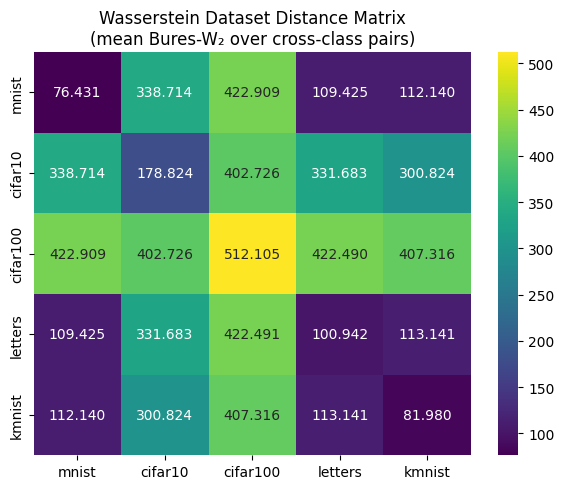

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Тепловая карта попарных расстояний между датасетами
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(D_dataset, annot=True, fmt='.3f',
            xticklabels=dataset_names, yticklabels=dataset_names,
            cmap='viridis', ax=ax)
ax.set_title('Wasserstein Dataset Distance Matrix\n(mean Bures-W₂ over cross-class pairs)')
plt.tight_layout()
plt.show()

In [5]:
# DataFrame с рекомендациями по предобучению на основе Wasserstein
n = len(dataset_names)
rows = []
for i, name in enumerate(dataset_names):
    closest = dataset2closest[name]
    j = dataset_names.index(closest)
    rows.append({
        'downstream': name,
        'recommended_pretrain': closest,
        'wasserstein_distance': round(D_dataset[i, j], 4),
    })

recommendations_df = pd.DataFrame(rows).set_index('downstream')
recommendations_df

,recommended_pretrain,wasserstein_distance
downstream,,
mnist,letters,109.4255
cifar10,kmnist,300.8243
cifar100,cifar10,402.7262
letters,mnist,109.4255
kmnist,mnist,112.1396


In [6]:
from IPython.display import display

logs_available = LOGS_PATH.exists() and any(LOGS_PATH.glob("*.yaml"))

if logs_available:
    wasserstein_res = get_wasserstein_results(dataset_names, embedder)
    rows = []
    for name in dataset_names:
        closest = dataset2closest[name]
        j = dataset_names.index(closest)
        rows.append({
            'downstream': name,
            'recommended_pretrain': closest,
            'wasserstein_distance': round(D_dataset[dataset_names.index(name), j], 4),
            'accuracy': wasserstein_res[name]['accuracy'],
        })
    display(pd.DataFrame(rows).set_index('downstream'))
else:
    print(f"Логи не найдены в {LOGS_PATH}")
    print("Запустите get_pretrained_to_task.py чтобы получить accuracy.")

Closest pretraining dataset per task:
  mnist → letters
  cifar10 → kmnist
  cifar100 → cifar10
  letters → mnist
  kmnist → mnist


,recommended_pretrain,wasserstein_distance,accuracy
downstream,,,
mnist,letters,109.4255,0.98970
cifar10,kmnist,300.8243,0.61880
cifar100,cifar10,402.7262,0.49600
letters,mnist,109.4255,0.93351
kmnist,mnist,112.1396,0.99570
